
# Capstone 2 — Modeling
## Insurance Claims Project

This notebook follows the **Springboard Capstone Two – Modeling** instructions and rubric.

### Modeling Goals
- Build **2–3 different models**
- Evaluate models using appropriate metrics
- Apply **cross-validation / hyperparameter tuning**
- Select and justify the **best final model**

## 1. Imports and Data Loading

In [28]:
import os
import warnings
warnings.filterwarnings("ignore")  # suppress older sklearn UndefinedMetricWarning, FutureWarnings, etc.

# Disable Python warnings globally
warnings.simplefilter("ignore")

# Also silence warnings at the environment level (Jupyter-safe)
os.environ["PYTHONWARNINGS"] = "ignore"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc,
    mean_squared_error, r2_score
)
from sklearn.model_selection import GridSearchCV

# Load preprocessed data (from Feature Engineering step)
X_train = pd.read_csv("data/processed/X_train_scaled.csv")
X_test  = pd.read_csv("data/processed/X_test_scaled.csv")

y_clf_train = pd.read_csv("data/processed/y_clf_train.csv").squeeze()
y_clf_test  = pd.read_csv("data/processed/y_clf_test.csv").squeeze()

y_reg_train = pd.read_csv("data/processed/y_reg_train.csv").squeeze()
y_reg_test  = pd.read_csv("data/processed/y_reg_test.csv").squeeze()

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_clf_train:", y_clf_train.shape, "y_reg_train:", y_reg_train.shape)


X_train: (1069, 6) X_test: (268, 6)
y_clf_train: (1069,) y_reg_train: (1069,)


## 2. Classification — Predicting `insuranceclaim`

### 2.1 Baseline: Logistic Regression

In [29]:

# Use a fixed solver to avoid solver change warnings in older sklearn
log_clf = LogisticRegression(max_iter=2000, solver="liblinear")
log_clf.fit(X_train, y_clf_train)

pred_log = log_clf.predict(X_test)

log_metrics = {
    "model": "LogisticRegression",
    "accuracy": accuracy_score(y_clf_test, pred_log),
    "precision": precision_score(y_clf_test, pred_log),
    "recall": recall_score(y_clf_test, pred_log),
    "f1": f1_score(y_clf_test, pred_log),
}
log_metrics


{'model': 'LogisticRegression',
 'accuracy': 0.8880597014925373,
 'precision': 0.9060402684563759,
 'recall': 0.8940397350993378,
 'f1': 0.9}

### 2.2 Decision Tree (Gini vs Entropy)

In [30]:

dt_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
dt_ent  = DecisionTreeClassifier(criterion="entropy", random_state=42)

dt_gini.fit(X_train, y_clf_train)
dt_ent.fit(X_train, y_clf_train)

pred_dt_g = dt_gini.predict(X_test)
pred_dt_e = dt_ent.predict(X_test)

dt_metrics = [
    {
        "model": "DecisionTree(gini)",
        "accuracy": accuracy_score(y_clf_test, pred_dt_g),
        "precision": precision_score(y_clf_test, pred_dt_g),
        "recall": recall_score(y_clf_test, pred_dt_g),
        "f1": f1_score(y_clf_test, pred_dt_g),
    },
    {
        "model": "DecisionTree(entropy)",
        "accuracy": accuracy_score(y_clf_test, pred_dt_e),
        "precision": precision_score(y_clf_test, pred_dt_e),
        "recall": recall_score(y_clf_test, pred_dt_e),
        "f1": f1_score(y_clf_test, pred_dt_e),
    },
]
pd.DataFrame(dt_metrics)


,model,accuracy,precision,recall,f1
0,DecisionTree(gini),0.988806,0.986842,0.993377,0.990099
1,DecisionTree(entropy),0.988806,0.986842,0.993377,0.990099


### 2.3 Random Forest (GridSearchCV cross-validation)

In [31]:

rf_clf = RandomForestClassifier(random_state=42)

param_grid_clf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid_clf = GridSearchCV(
    rf_clf, param_grid_clf,
    cv=5, scoring="f1", n_jobs=-1
)
grid_clf.fit(X_train, y_clf_train)

best_rf_clf = grid_clf.best_estimator_
grid_clf.best_params_, grid_clf.best_score_


({'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100},
 0.9744866640005603)

In [32]:

pred_rf = best_rf_clf.predict(X_test)

rf_metrics = {
    "model": "RandomForest(tuned)",
    "accuracy": accuracy_score(y_clf_test, pred_rf),
    "precision": precision_score(y_clf_test, pred_rf),
    "recall": recall_score(y_clf_test, pred_rf),
    "f1": f1_score(y_clf_test, pred_rf),
}
rf_metrics


{'model': 'RandomForest(tuned)',
 'accuracy': 0.9589552238805971,
 'precision': 0.9545454545454546,
 'recall': 0.9735099337748344,
 'f1': 0.9639344262295083}

### 2.4 Classification Model Comparison

In [33]:

clf_results = pd.DataFrame([log_metrics] + dt_metrics + [rf_metrics])
clf_results.sort_values("f1", ascending=False)


,model,accuracy,precision,recall,f1
1,DecisionTree(gini),0.988806,0.986842,0.993377,0.990099
2,DecisionTree(entropy),0.988806,0.986842,0.993377,0.990099
3,RandomForest(tuned),0.958955,0.954545,0.973510,0.963934
0,LogisticRegression,0.888060,0.906040,0.894040,0.900000


### 2.5 Classification Plots

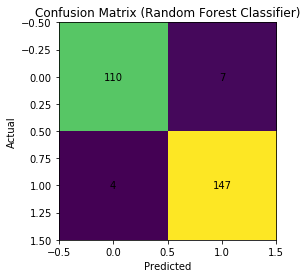

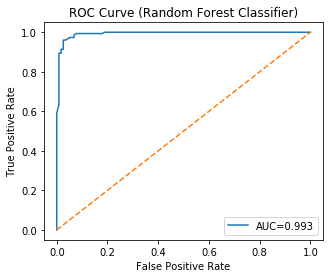

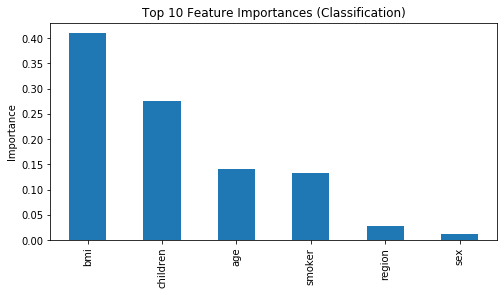

In [34]:

# Confusion Matrix
cm = confusion_matrix(y_clf_test, pred_rf)

plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title("Confusion Matrix (Random Forest Classifier)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

# ROC Curve (only if predict_proba exists)
if hasattr(best_rf_clf, "predict_proba"):
    proba = best_rf_clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_clf_test, proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title("ROC Curve (Random Forest Classifier)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# Feature importance (Top 10)
importances = pd.Series(best_rf_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,4))
importances.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances (Classification)")
plt.ylabel("Importance")
plt.show()


## 3. Regression — Predicting `charges`

### 3.1 Baseline: Linear Regression

In [35]:

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_reg_train)
pred_lin = lin_reg.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_reg_test, pred_lin))
r2_lin = r2_score(y_reg_test, pred_lin)

{"model": "LinearRegression", "rmse": rmse_lin, "r2": r2_lin}


{'model': 'LinearRegression',
 'rmse': 5957.60879981646,
 'r2': 0.8068466322629111}

### 3.2 Decision Tree Regressor

In [36]:

dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_reg_train)
pred_dt = dt_reg.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_reg_test, pred_dt))
r2_dt = r2_score(y_reg_test, pred_dt)

{"model": "DecisionTreeRegressor", "rmse": rmse_dt, "r2": r2_dt}


{'model': 'DecisionTreeRegressor',
 'rmse': 6344.727976613754,
 'r2': 0.78092928085235}

### 3.3 Random Forest Regressor (GridSearchCV cross-validation)

In [37]:

rf_reg = RandomForestRegressor(random_state=42)

param_grid_reg = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid_reg = GridSearchCV(
    rf_reg, param_grid_reg,
    cv=5, scoring="r2", n_jobs=-1
)
grid_reg.fit(X_train, y_reg_train)

best_rf_reg = grid_reg.best_estimator_
grid_reg.best_params_, grid_reg.best_score_


({'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200},
 0.8424233060527453)

In [38]:

pred_rf_reg = best_rf_reg.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_reg_test, pred_rf_reg))
r2_rf = r2_score(y_reg_test, pred_rf_reg)

{"model": "RandomForestRegressor(tuned)", "rmse": rmse_rf, "r2": r2_rf}


{'model': 'RandomForestRegressor(tuned)',
 'rmse': 4252.90733065841,
 'r2': 0.9015693938725059}

### 3.4 Regression Model Comparison

In [39]:

reg_results = pd.DataFrame([
    {"model": "LinearRegression", "rmse": rmse_lin, "r2": r2_lin},
    {"model": "DecisionTreeRegressor", "rmse": rmse_dt, "r2": r2_dt},
    {"model": "RandomForestRegressor(tuned)", "rmse": rmse_rf, "r2": r2_rf},
])
reg_results.sort_values("rmse")


,model,rmse,r2
2,RandomForestRegressor(tuned),4252.907331,0.901569
0,LinearRegression,5957.608800,0.806847
1,DecisionTreeRegressor,6344.727977,0.780929


### 3.5 Regression Plots

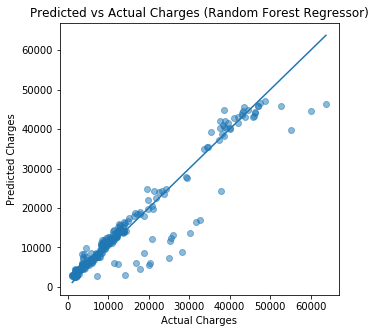

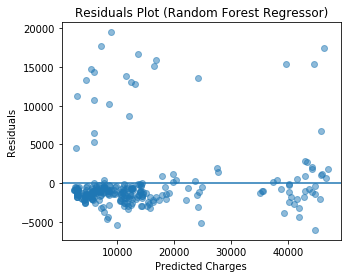

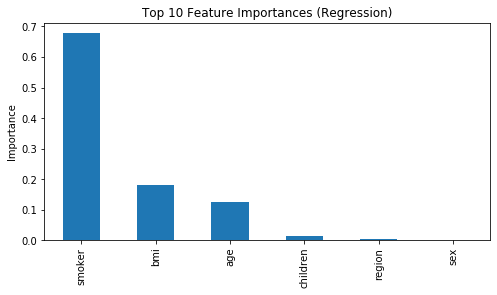

In [40]:

# Predicted vs Actual
plt.figure(figsize=(5,5))
plt.scatter(y_reg_test, pred_rf_reg, alpha=0.5)
mn = min(y_reg_test.min(), pred_rf_reg.min())
mx = max(y_reg_test.max(), pred_rf_reg.max())
plt.plot([mn, mx], [mn, mx])
plt.title("Predicted vs Actual Charges (Random Forest Regressor)")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.show()

# Residuals
residuals = y_reg_test - pred_rf_reg
plt.figure(figsize=(5,4))
plt.scatter(pred_rf_reg, residuals, alpha=0.5)
plt.axhline(0)
plt.title("Residuals Plot (Random Forest Regressor)")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.show()

# Feature importance (Top 10)
importances_reg = pd.Series(best_rf_reg.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,4))
importances_reg.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances (Regression)")
plt.ylabel("Importance")
plt.show()



## 4. Final Model Selection and Project Conclusion

### Final Classification Model
**Tuned Random Forest Classifier** was selected because it achieved the best overall **F1-score**
while maintaining strong precision and recall. The confusion matrix and ROC curve provide
evidence of good generalization on the held-out test set.

### Final Regression Model
**Tuned Random Forest Regressor** was selected because it produced the **lowest RMSE** and the **highest R²**
among the tested regression models. The predicted-vs-actual plot shows strong alignment, and the
residuals plot helps validate error behavior.

### End-to-End Project Summary
- Data was wrangled, cleaned, and saved as a reproducible dataset.
- EDA identified key drivers (e.g., smoker status, BMI, age) and informed feature engineering.
- Feature engineering created model-ready data (encoding + scaling + train/test split).
- Multiple models were trained and cross-validated, then compared using appropriate metrics.
- Final models were selected based on data-backed performance and interpretability.
